In [2]:
import sys

sys.path.insert(0, "../")
import matplotlib.pyplot as plt
from modules.functions_v3 import *

plt.rcParams["figure.dpi"] = 200

/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v3.py:23: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):
/Users/fairytien/Documents/TEXAS_Bridge_2324/code/lensing_and_precession/notebooks/../modules/Classes_v3.py:23: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _name):


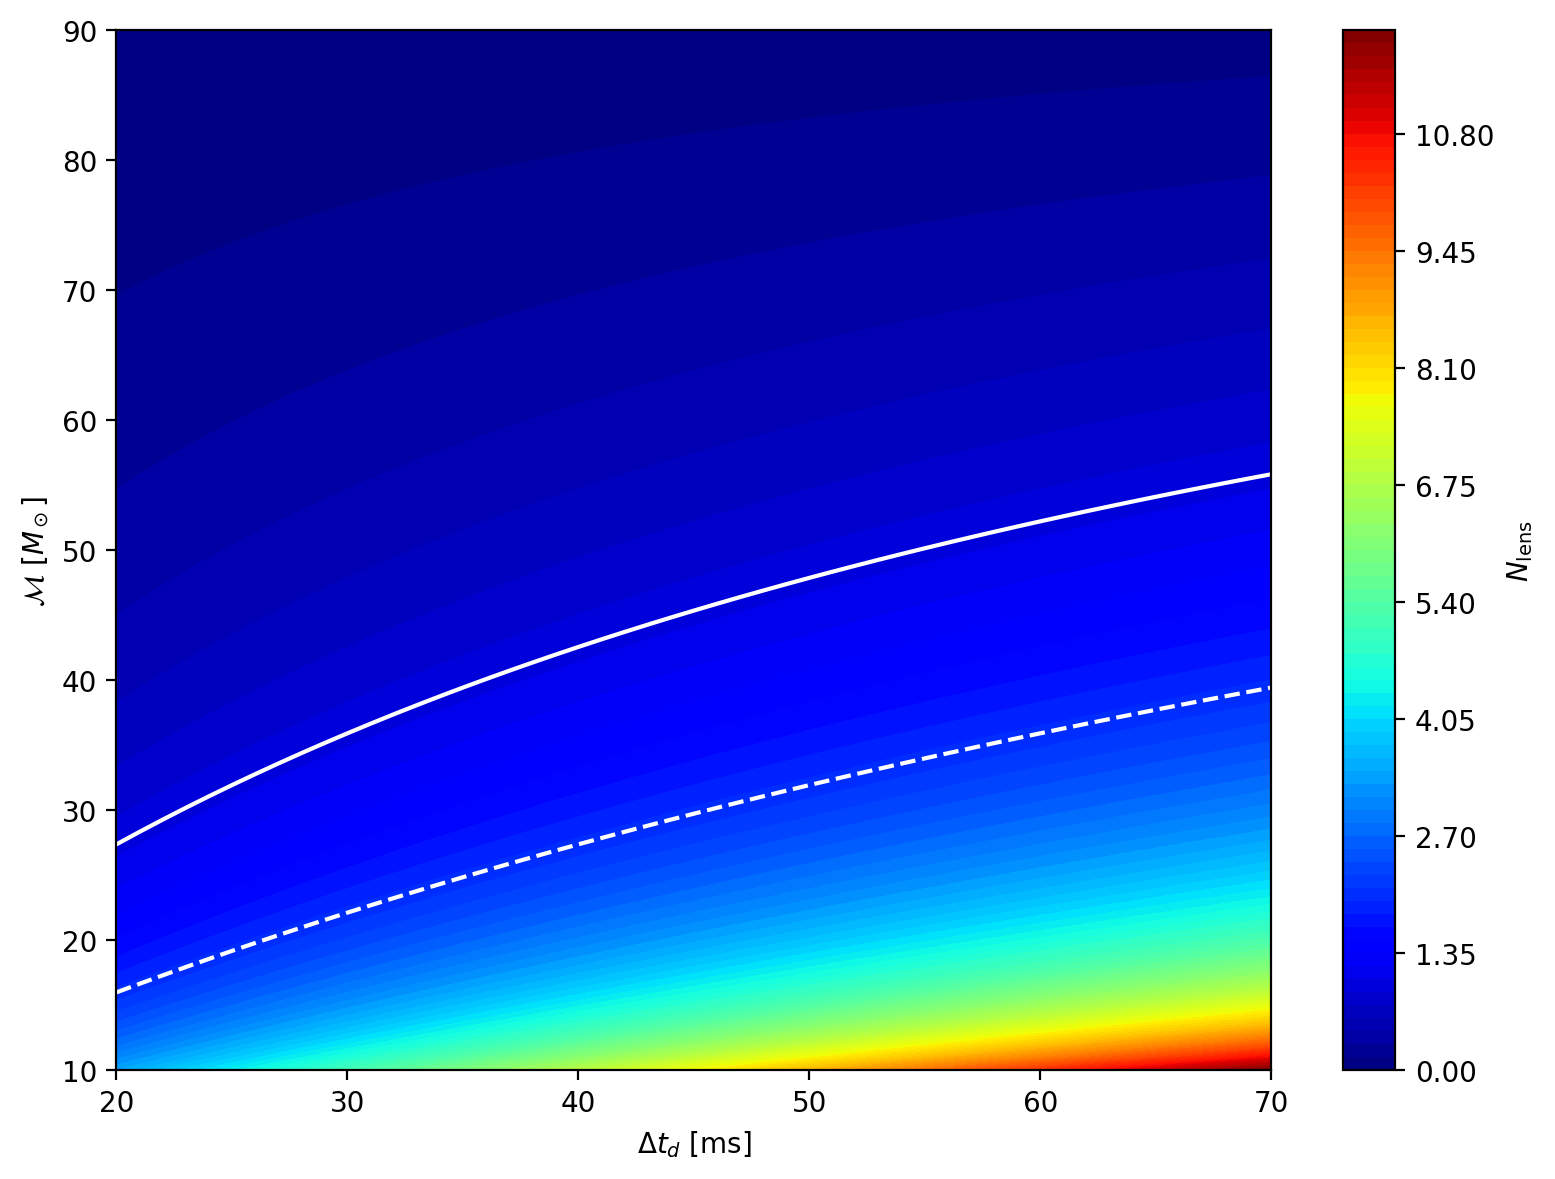

In [3]:
mcz_arr = np.linspace(10, 90, 81)  # [M_sun]
td_arr = np.linspace(0.02, 0.07, 51)  # [sec]
TD, MCZ = np.meshgrid(td_arr, mcz_arr)
Z = number_of_lens_cycles(MCZ, TD)  # [dimensionless]
mcz_1lens = mcz_for_n_lens_cycles(1.0, td_arr, f_min=20, eta=0.25)
mcz_2lens = mcz_for_n_lens_cycles(2.0, td_arr, f_min=20, eta=0.25)

plt.figure(figsize=(8, 6))
cf = plt.contourf(TD * 1e3, MCZ, Z, levels=100, cmap="jet")
cbar = plt.colorbar(cf)
cbar.set_label(r"$N_\mathrm{lens}$")
plt.xlabel(r"$\Delta t_d$ [ms]")
plt.ylabel(r"$\mathcal{M}\ [M_\odot]$")

plt.plot(td_arr * 1e3, mcz_1lens, color="white", ls="-", label="1 cycle")
plt.plot(td_arr * 1e3, mcz_2lens, color="white", ls="--", label="2 cycles")

plt.tight_layout()
plt.savefig("../figures/n_lens_mcz_td.pdf")

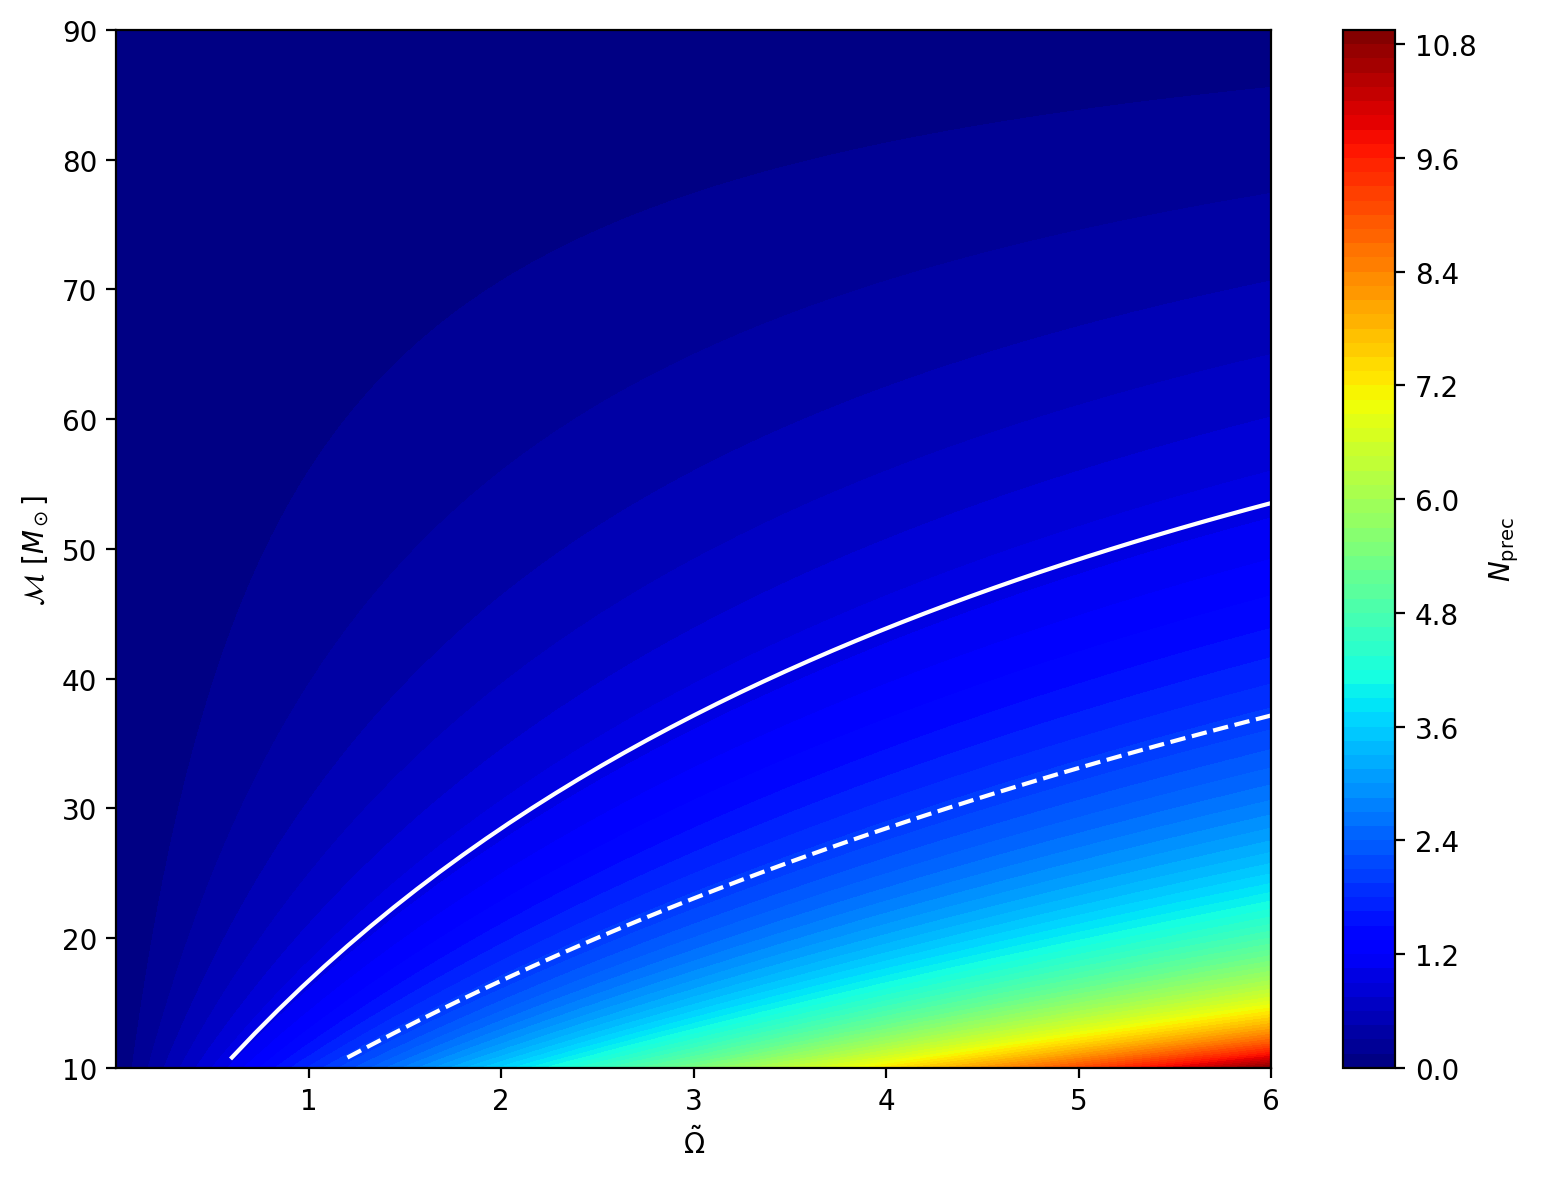

In [6]:
mcz_arr = np.linspace(10, 90, 81)  # [M_sun]
omega_arr = np.linspace(0.001, 6, 51)  # [dimensionless]
OMEGA, MCZ = np.meshgrid(omega_arr, mcz_arr)
Z = number_of_prec_cycles(MCZ, OMEGA)  # [dimensionless]
mcz_1prec = mcz_for_n_prec_cycles(1.0, omega_arr, f_min=20, eta=0.25)
mcz_2prec = mcz_for_n_prec_cycles(2.0, omega_arr, f_min=20, eta=0.25)

# Cut off mcz_1prec and mcz_2prec at 10 Msun
mcz_1prec = np.where(mcz_1prec < 10, np.nan, mcz_1prec)
mcz_2prec = np.where(mcz_2prec < 10, np.nan, mcz_2prec)

plt.figure(figsize=(8, 6))
cf = plt.contourf(OMEGA, MCZ, Z, levels=100, cmap="jet")
cbar = plt.colorbar(cf)
cbar.set_label(r"$N_\mathrm{prec}$")
plt.xlabel(r"$\tilde{\Omega}$")
plt.ylabel(r"$\mathcal{M}\ [M_\odot]$")

plt.plot(omega_arr, mcz_1prec, color="white", ls="-", label="1 cycle")
plt.plot(omega_arr, mcz_2prec, color="white", ls="--", label="2 cycles")

plt.tight_layout()
plt.savefig("../figures/n_prec_mcz_omega.pdf")

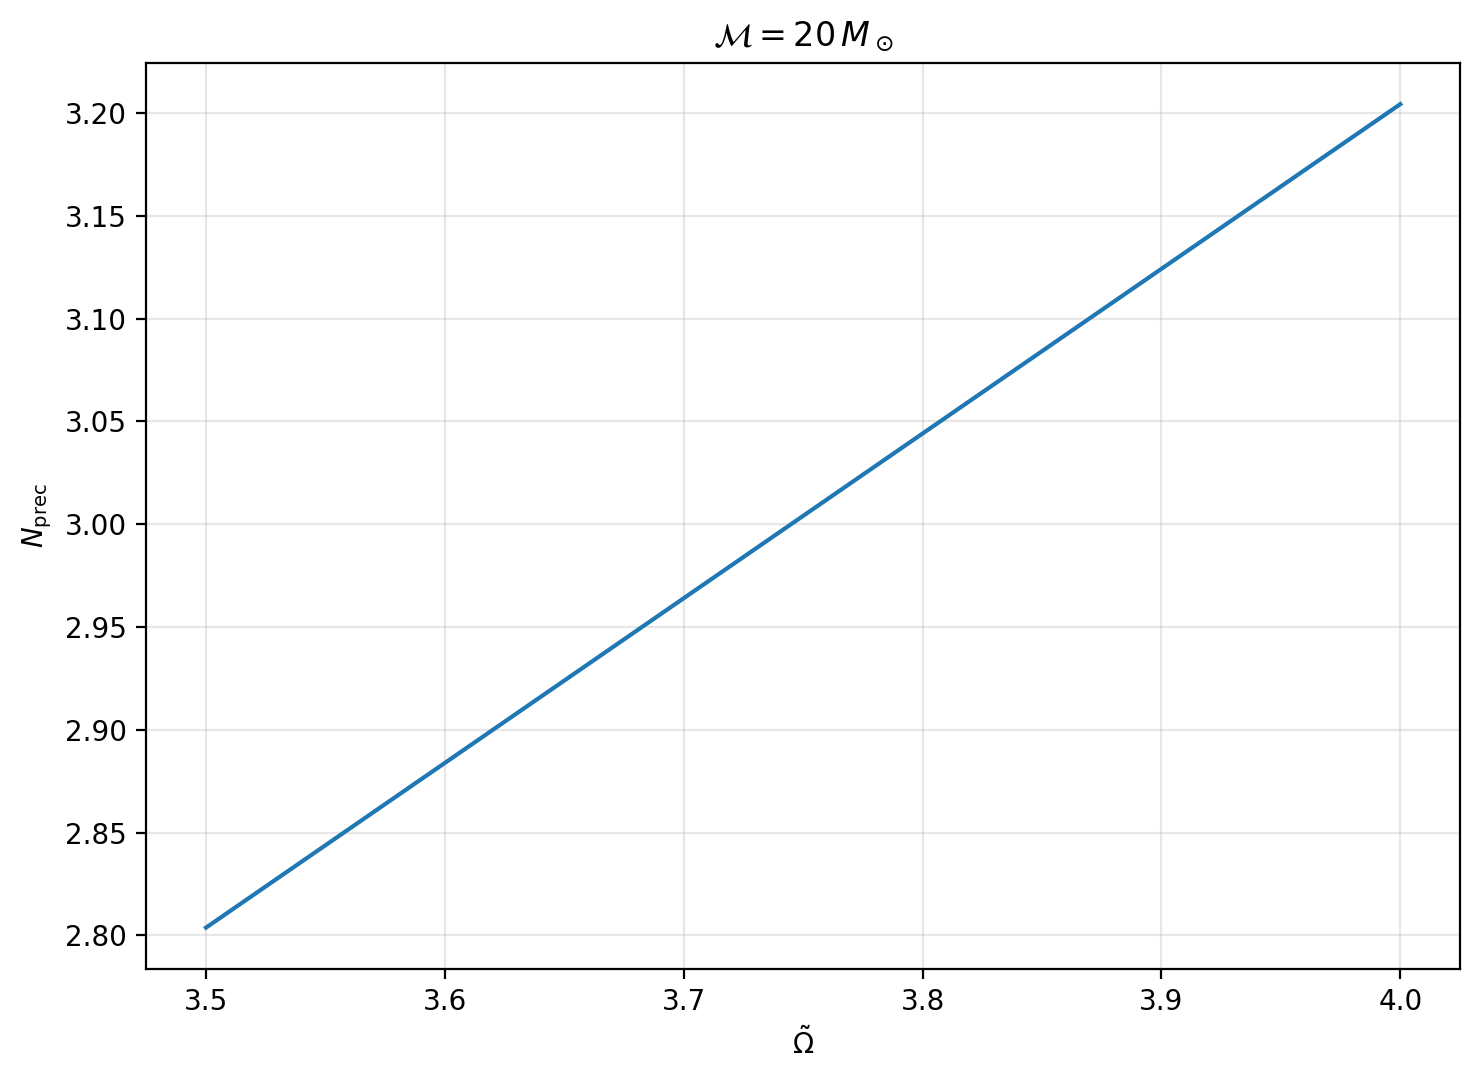

In [ ]:
omega_arr = np.linspace(3.5, 4, 51)  # [dimensionless]
mcz = 20  # [M_sun]
nprec_arr = number_of_prec_cycles(mcz, omega_arr)  # [dimensionless]

plt.figure(figsize=(7.5, 5.5))
plt.plot(omega_arr, nprec_arr)
plt.xlabel(r"$\tilde{\Omega}$")
plt.ylabel(r"$N_\mathrm{prec}$")
plt.title(rf"$\mathcal{{M}}={mcz:.0f}\,M_\odot$")
plt.grid(True, alpha=0.3)
plt.tight_layout()